## Importing Libraries

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Importing the dataset

In [81]:
# fetching dataset from sklearn.datasets already existing datasets
from sklearn.datasets import fetch_california_housing

In [82]:
housing=fetch_california_housing()

In [83]:
type(housing)

sklearn.utils.Bunch

In [84]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [85]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block
        - HouseAge      median house age in block
        - AveRooms      average number of rooms
        - AveBedrms     average number of bedrooms
        - Population    block population
        - AveOccup      average house occupancy
        - Latitude      house block latitude
        - Longitude     house block longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
http://lib.stat.cmu.edu/datasets/

The target variable is the median house value for California districts.

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bur

In [86]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [87]:
print(housing.target_names)

['MedHouseVal']


## Prepare the dataset

In [88]:
# converting the data into dataframe

data=pd.DataFrame(housing.data, columns=housing.feature_names)

In [89]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [90]:
# now attaching the target values

data["Price"]=housing.target

In [91]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [93]:
data.isnull().sum()
# no null values

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [94]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Exploratory Data Analysis

#### Outlier Removal

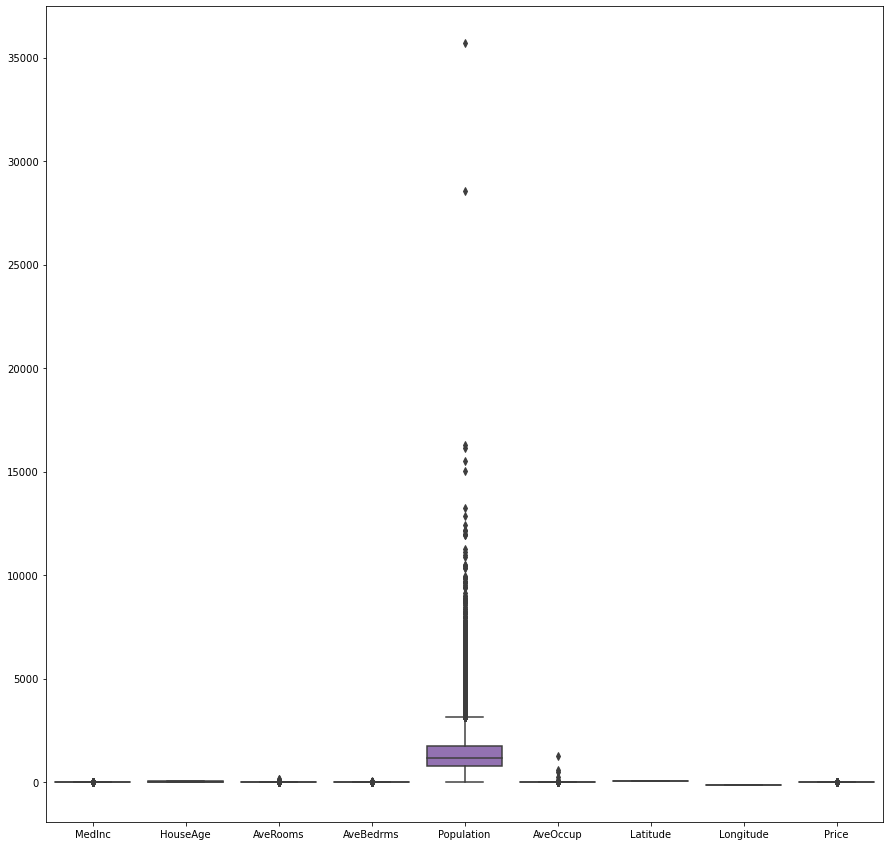

In [95]:
# Outlier Detection

fig, ax= plt.subplots(figsize=(15,15))

sns.boxplot(data=data, ax=ax)
plt.savefig("boxAndWhiskerPlot.png")

In [96]:
def outlier_detection(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    
    IQR = Q3-Q1
    
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    outliers = data[(data[col]<lower_bound)|(data[col]>upper_bound)]
    
    outlier_percent = len(outliers)/len(data)*100
    
    print(f"{col}: {len(outliers)} outliers ({outlier_percent:.2f}%), "
          f"bounds = [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    return upper_bound, lower_bound

In [97]:
# removing Outliers
def capping_outliers(data,col,upper_bound, lower_bound):
    data[col]=data[col].clip(lower_bound,upper_bound)


<hr>
<ol>
    <li> If a column has <1% outliers → usually safe to leave alone, not worth the fuss.</li>
<li>If a column has a meaningful chunk (5%+), like AveBedrms or Population in this dataset → worth treating.</li>
    </ol>
<br>
<b> Note: <b>
<ul>
    <li>Latitude/Longitude don't really have "outliers" in the statistical sense — every value is a real place in California</li>
<li>Remove Price columns as well</li>
    </ul>
    <hr>

In [98]:
data['AveOccup'].describe()

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

AveOccup columns have extreme values, need to cap this columns for outlier removal

In [99]:
for col in data.columns[:-3]:
    outlier_detection(data,col)

MedInc: 681 outliers (3.30%), bounds = [-0.71, 8.01]
HouseAge: 0 outliers (0.00%), bounds = [-10.50, 65.50]
AveRooms: 511 outliers (2.48%), bounds = [2.02, 8.47]
AveBedrms: 1424 outliers (6.90%), bounds = [0.87, 1.24]
Population: 1196 outliers (5.79%), bounds = [-620.00, 3132.00]
AveOccup: 711 outliers (3.44%), bounds = [1.15, 4.56]


In [100]:
for col in ['AveRooms','AveBedrms','Population','AveOccup']:
    upper_bound , lower_bound = outlier_detection(data,col)
    capping_outliers(data, col, upper_bound , lower_bound)

AveRooms: 511 outliers (2.48%), bounds = [2.02, 8.47]
AveBedrms: 1424 outliers (6.90%), bounds = [0.87, 1.24]
Population: 1196 outliers (5.79%), bounds = [-620.00, 3132.00]
AveOccup: 711 outliers (3.44%), bounds = [1.15, 4.56]


In [101]:
for col in data.columns[:-3]:
    outlier_detection(data,col)

MedInc: 681 outliers (3.30%), bounds = [-0.71, 8.01]
HouseAge: 0 outliers (0.00%), bounds = [-10.50, 65.50]
AveRooms: 0 outliers (0.00%), bounds = [2.02, 8.47]
AveBedrms: 0 outliers (0.00%), bounds = [0.87, 1.24]
Population: 0 outliers (0.00%), bounds = [-620.00, 3132.00]
AveOccup: 0 outliers (0.00%), bounds = [1.15, 4.56]


In [102]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.304740,1.057958,1336.959012,2.899647,35.631861,-119.569704,2.068558
std,1.899822,12.585558,1.246177,0.080448,765.550830,0.691142,2.135952,2.003532,1.153956
min,0.499900,1.000000,2.023219,0.865909,3.000000,1.150961,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,8.469878,1.239697,3132.000000,4.561041,41.950000,-114.310000,5.000010


<B> Checking for correlated features</B>

In [103]:
data.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.648751,-0.209465,-0.014028,-0.060625,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.230360,-0.132477,-0.307620,-0.006318,0.011173,-0.108197,0.105623
AveRooms,0.648751,-0.230360,1.000000,0.176210,-0.097907,-0.035624,0.128647,-0.068379,0.311003
AveBedrms,-0.209465,-0.132477,0.176210,1.000000,0.002474,-0.121060,0.063221,0.011850,-0.096055
Population,-0.014028,-0.307620,-0.097907,0.002474,1.000000,0.225746,-0.133225,0.116115,-0.032739
AveOccup,-0.060625,-0.006318,-0.035624,-0.121060,0.225746,1.000000,-0.170149,0.178649,-0.281148
Latitude,-0.079809,0.011173,0.128647,0.063221,-0.133225,-0.170149,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.068379,0.011850,0.116115,0.178649,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.311003,-0.096055,-0.032739,-0.281148,-0.144160,-0.045967,1.000000


1. AveRooms & AveBedrms are correlated => 0.847621
2. Latitude & Longitude => -0.924664 (but important features)

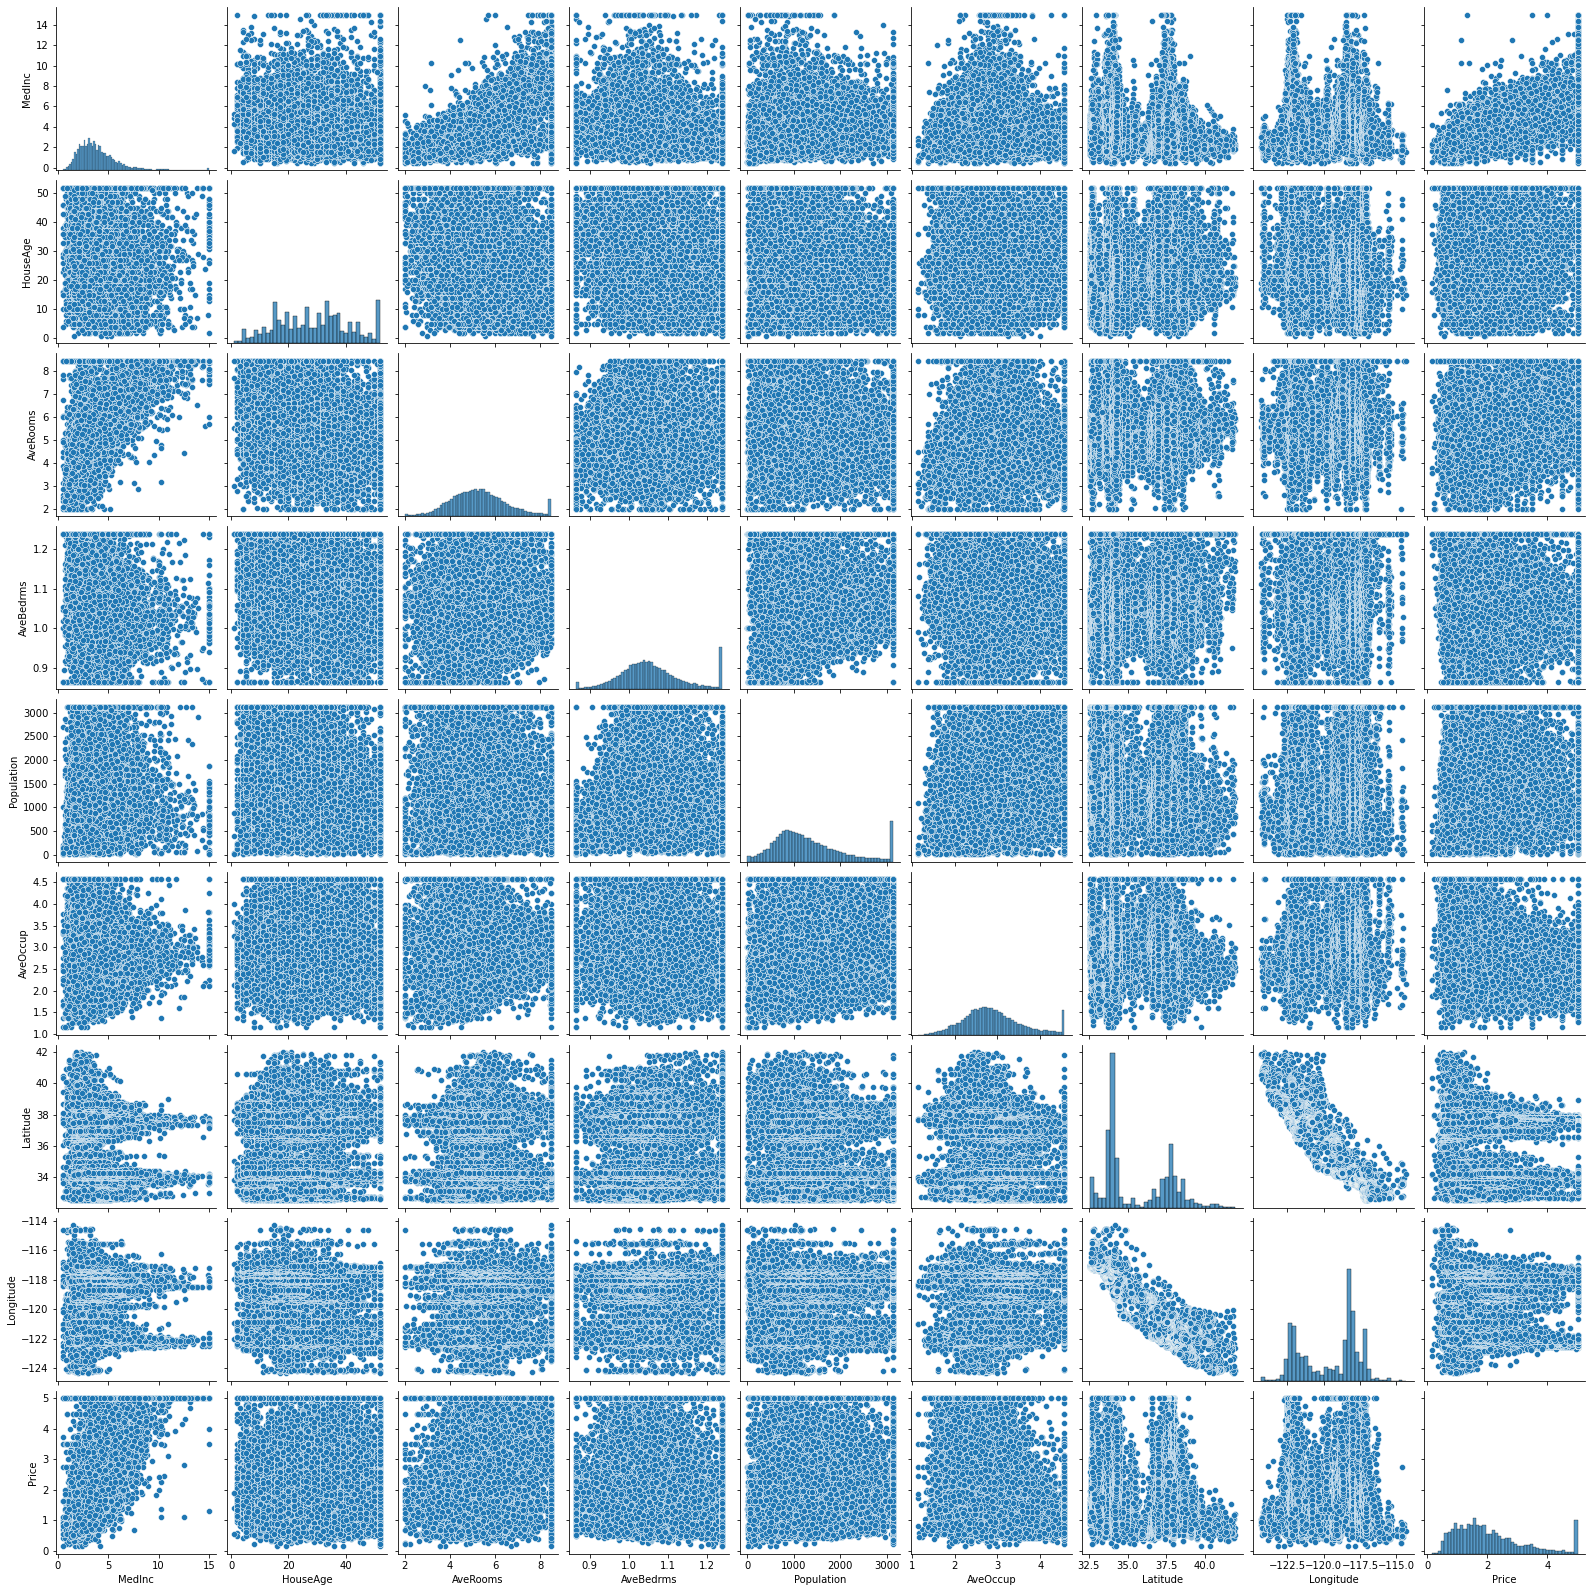

In [104]:
sns.pairplot(data)

##### Removing the correlated columns

In [105]:
# data.drop(['AveBedrms'],axis=1,inplace=True)

In [106]:
# no need to drop any columns, as no strong correlation between features

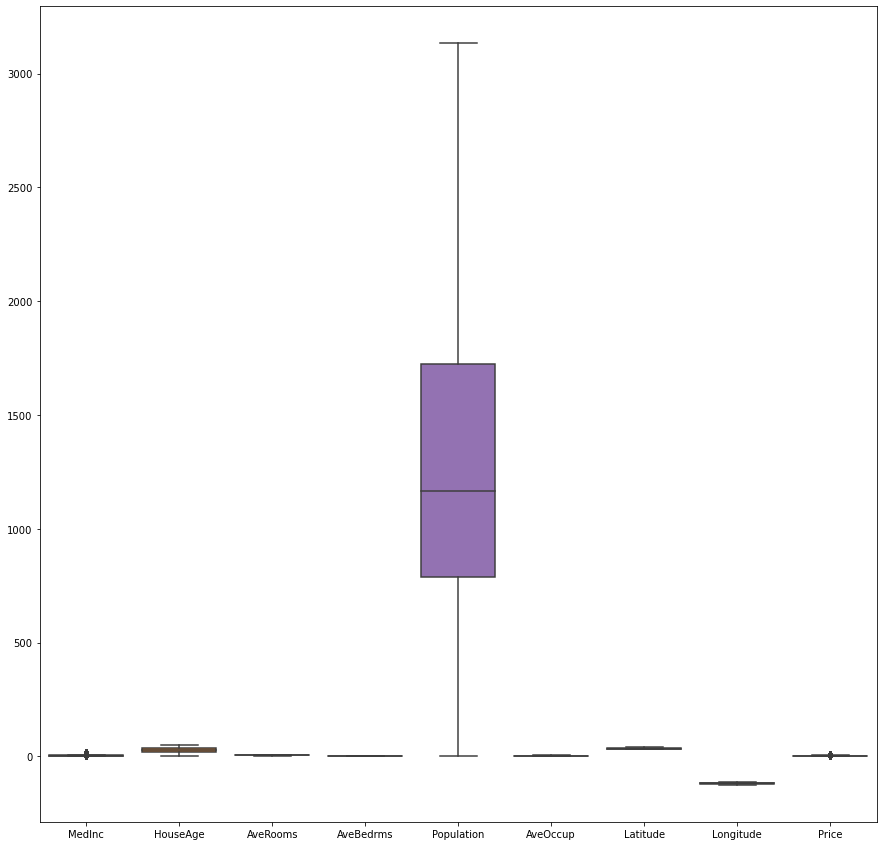

In [107]:
fig, ax= plt.subplots(figsize=(15,15))

sns.boxplot(data=data, ax=ax)
plt.savefig("boxAndWhiskerPlot.png")

Trying to normalize the feature values as population feature have large range for values as compared to other features

#### Separating the dependent and independent features

In [108]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]

# x=> independent variable
# y=> dependent variable

In [109]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [110]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

#### Splitting data into Training and Testing data

In [111]:
from sklearn.model_selection import train_test_split

In [112]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [113]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.239697,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [114]:
x_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
17505,2.9545,47.0,4.195833,1.020833,581.0,2.420833,37.36,-121.90
13512,1.4891,41.0,4.551852,1.118519,994.0,3.681481,34.11,-117.32
10842,3.5120,16.0,3.762287,1.075614,3132.0,2.369565,33.67,-117.91
16559,3.6500,10.0,5.502092,1.060371,3132.0,3.547519,37.82,-121.28


##### Standardlization

In [115]:
from sklearn.preprocessing import StandardScaler

In [116]:
scaler=StandardScaler()

In [117]:
x_train_norm=scaler.fit_transform(x_train)

In [118]:
x_train_norm

array([[ 0.13350629,  0.50935748,  0.45706171, ...,  0.12712328,
        -0.80568191,  0.78093406],
       [-0.53221805, -0.67987313, -0.72902794, ..., -1.27699695,
        -1.33947268,  1.24526986],
       [ 0.1709897 , -0.36274497,  0.24500436, ..., -0.48065891,
        -0.49664515, -0.27755183],
       ...,
       [-0.49478713,  0.58863952, -1.06095069, ...,  0.62848457,
        -0.75885816,  0.60119118],
       [ 0.96717102, -1.07628333,  0.8678654 , ...,  0.40702277,
         0.90338501, -1.18625198],
       [-0.68320166,  1.85715216, -1.52872673, ..., -1.14025054,
         0.99235014, -1.41592345]])

<AxesSubplot:>

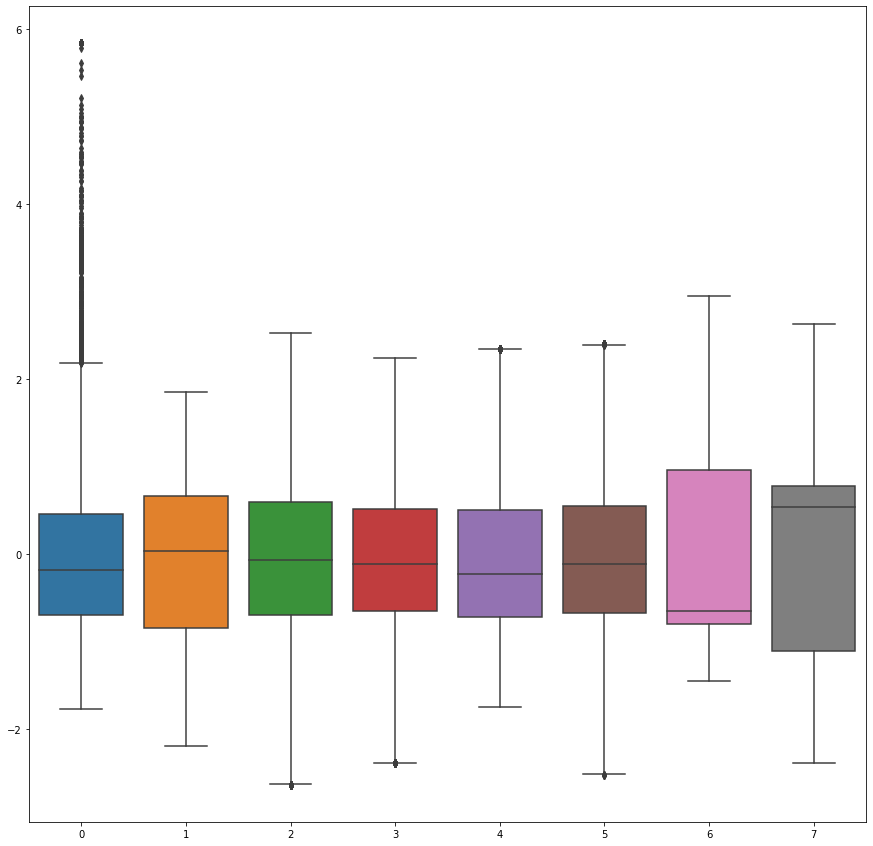

In [119]:
fig, ax= plt.subplots(figsize=(15,15))

sns.boxplot(data=x_train_norm, ax=ax)

In [120]:
x_test_norm=scaler.transform(x_test)

In [121]:
x_test_norm

array([[-1.1526893 , -0.28346293, -0.89640105, ...,  1.41697147,
         0.19166399,  0.28664112],
       [-0.70640568,  0.11294728, -0.21798255, ..., -0.31456377,
        -0.23911452,  0.06196251],
       [-0.20830675,  1.85715216, -1.06860831, ..., -2.22222383,
         1.00639726, -1.42590916],
       ...,
       [-0.19155996, -0.99700129, -1.24067269, ..., -0.76308896,
        -0.92742367,  0.8358555 ],
       [-0.11911302, -1.47269353,  0.15255132, ...,  0.93998078,
         1.01576201, -0.84673764],
       [-0.43304974, -0.91771925, -1.56619989, ..., -0.40825197,
        -0.70266966,  0.67109119]])

<AxesSubplot:>

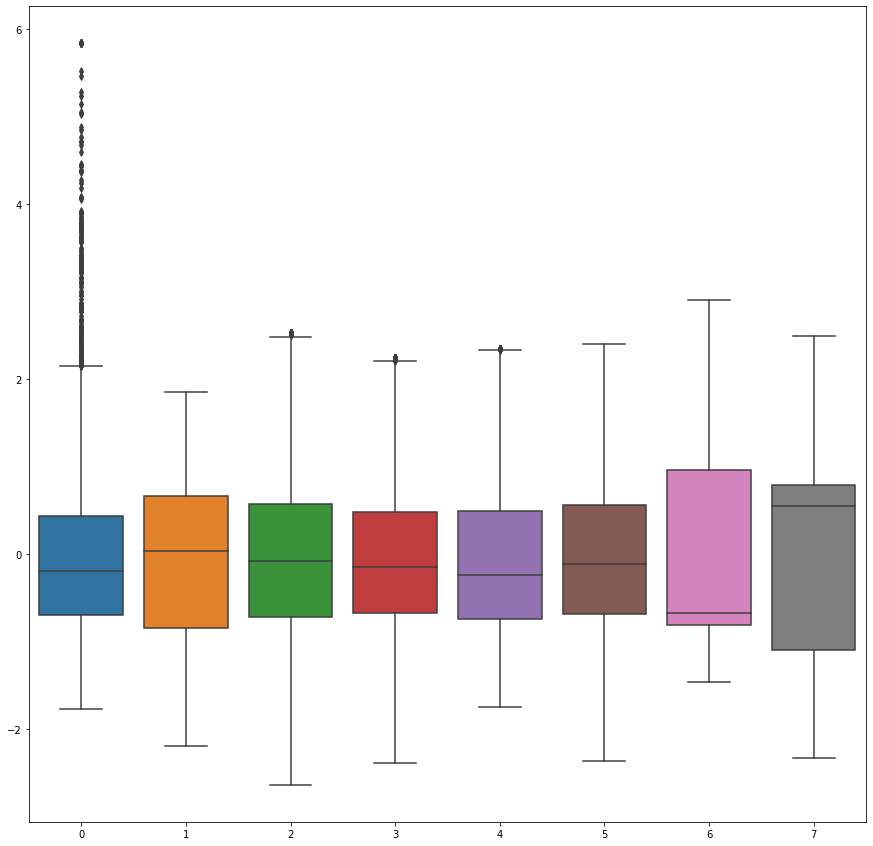

In [122]:
fig, ax= plt.subplots(figsize=(15,15))

sns.boxplot(data=x_test_norm, ax=ax)

#####  Model Training

In [123]:
from sklearn.linear_model import LinearRegression

In [124]:
regression=LinearRegression()

In [125]:
regression.fit(x_train_norm,y_train)

LinearRegression()

In [126]:
regression.coef_

array([ 0.80180669,  0.14689044, -0.09455209,  0.12849177,  0.04955146,
       -0.28362583, -0.8984959 , -0.82142074])

In [127]:
regression.intercept_

2.0692396089424165

#####  Predicting values

In [128]:
prediction=regression.predict(x_test_norm)
prediction

array([0.32401696, 2.02254248, 3.37404024, ..., 2.39281191, 1.37815326,
       1.98530766])

#####  Calculating error

In [129]:
residual = y_test - prediction

In [130]:
residual

20046    0.152983
3024    -1.564542
15663    1.625970
20484   -0.427499
9814     0.068024
           ...   
17505    0.078331
13512   -0.064353
10842   -0.208812
16559   -0.184153
5786     0.112692
Name: Price, Length: 6192, dtype: float64

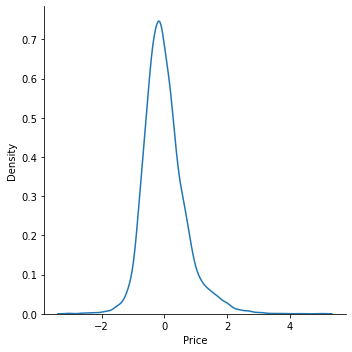

In [131]:
# distribution plot to see the distribution of residual

sns.displot(residual, kind="kde")

In [132]:
# the distribution looks like normal distribution

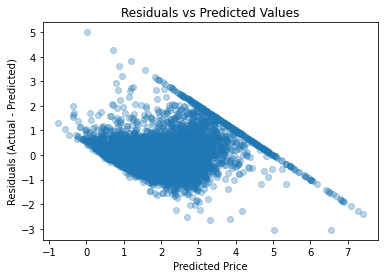

In [133]:
plt.scatter(prediction, residual, alpha=0.3)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.show()

Graph shows a funnel / cone shape and a straight line

Funnel shape => Heteroscedasticity => not a constant variance/spread of error<br>
Solution => Transforming the target

In [134]:
# Reason for straight line 
# the price is capped at 5.00001, prediction of those rows may be higher than the capped value
# residual = actual - predicted
# we don't know the actual, as it is capped at 5.00001
# residual = 5.00001 - predicted
# predicted inc => residual dec 

print((y_test == y_test.max()).sum(), "rows at the price ceiling")
print(y_test.max())

275 rows at the price ceiling
5.00001


#####  Performance Metrics

We want higher value for r2_score and adjusted r2_score
and lower value for mse, mae, and root_mean_square

In [135]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse=mean_squared_error(y_test,prediction)
mae=mean_absolute_error(y_test,prediction)
r2_score=r2_score(y_test,prediction)

In [136]:
# root mean square error

rmse=np.sqrt(mean_squared_error(y_test,prediction))
rmse

0.666405266023062

In [137]:
mse

0.44409597858326805

In [138]:
mae

0.49250565014108044

In [139]:
r2_score

0.6616514985412948

In [140]:
r2_adjusted=(1-((1-r2_score)*(len(y_test)))/((len(y_test))-x_train.shape[1]-1))

In [141]:
r2_adjusted

0.6611589970835674

##### Saving the Model

In [142]:
import pickle

In [143]:
pickle.dump(regression, open('housing_model.pkl','wb'))

##### Loading the model and making predictions

In [144]:
model = pickle.load(open('housing_model.pkl','rb'))

In [145]:
housing.data[0]

array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

In [146]:
arr=housing.data[0].reshape(1,-1)

In [147]:
predict=regression.predict(scaler.transform(arr))

In [148]:
predict

array([4.12564402])

In [149]:
housing.target[0]

4.526

<b> Checking if the model is overfitted or not </b>

In [150]:
train_predict=model.predict(x_train_norm)
test_predict=model.predict(x_test_norm)

In [151]:
rmse_train=np.sqrt(mean_squared_error(y_train,train_predict))
rmse_test=np.sqrt(mean_squared_error(y_test,test_predict))

In [152]:
rmse_train

0.667612578276586

In [153]:
rmse_test

0.666405266023062

`No need for Regularization as error for training dataset and test dataset is approximately equal`

#### Regularization - to avoid overfitting in the model

Just checking what would be the effect of Regularization when model is not overfitted

In [154]:
from sklearn.linear_model import Ridge, Lasso

In [155]:
lasso_regression=Lasso(alpha=0.1)
lasso_regression.fit(x_train_norm,y_train)

ridge_regression=Ridge(alpha=0.1)
ridge_regression.fit(x_train_norm,y_train)

Ridge(alpha=0.1)

In [156]:
lasso_predict=lasso_regression.predict(x_test_norm)

In [157]:
ridge_predict=ridge_regression.predict(x_test_norm)

In [158]:
rmse_lasso=np.sqrt(mean_squared_error(y_test,lasso_predict))
rmse_ridge=np.sqrt(mean_squared_error(y_test,ridge_predict))

In [159]:
rmse_lasso

0.7687250037375023

In [160]:
rmse_ridge

0.6664053849698254

In [161]:
print(dict(zip(x_train.columns, lasso_regression.coef_)))

{'MedInc': 0.6943470864609493, 'HouseAge': 0.10413464925738489, 'AveRooms': -0.0, 'AveBedrms': 0.0, 'Population': 0.0, 'AveOccup': -0.19211401125765373, 'Latitude': -0.043547172043219354, 'Longitude': -0.0}


As there is no overfitting, the lasso model(shrink the weights) is zeored out many useful features, that's why large rmse error.